# 04 — Pressing Intensity di unravelsports sui dati SkillCorner

**La domanda.** La Pressing Intensity di `unravelsports` (Bekkers 2025) gira sui
nostri dati? E sul portatore di palla, a inizio possesso, dice la stessa cosa di
τ_opp e di `time_to_impact`?

Una partita sola (`1886347`, la stessa del notebook 03): è un primo passo, non il
risultato sulle 20.

**Cosa calcola unravelsports.** Per ogni frame, una matrice difensori ×
attaccanti di *tempi di intercetto* (TTI) e la loro trasformazione in probabilità
(PTI). La formula è in `unravel/soccer/models/utils.py`:

$$
t = \underbrace{\lVert \vec v_d \rVert \,\frac{\theta}{\pi}}_{\text{cambio di direzione}}
  + \underbrace{t_r}_{\text{reazione, 0,7 s}}
  + \frac{\lVert (\vec x_a + \vec v_a) - (\vec x_d + \vec v_d\, t_r) \rVert}{v_{\max}}
$$

con $\theta$ l'angolo fra la velocità del difensore e la direzione verso il
bersaglio, e $v_{\max}$ = 12 m/s.

| | τ_opp (Narizuka et al., notebook 03) | TTI di unravelsports |
|---|---|---|
| Bersaglio | dove sta il portatore **adesso** | dove sarà l'attaccante **fra 1 s** ($\vec x_a + \vec v_a$) |
| Moto del difensore | massa con attrito: accelera da $\vec v_0$ verso $V_{\max}$ = 10 m/s | prosegue con $\vec v_d$ per 0,7 s, poi corre dritto a 12 m/s |
| Velocità del portatore | non conta | conta (sposta il bersaglio) |
| Valore minimo | 0 | 0,7 s (il tempo di reazione) |
| Velocità usate | derivata centrale, senza lisciatura | Savitzky–Golay di `KloppyPolarsDataset` |
| Squadra in possesso | da `player_possession` di SkillCorner | da kloppy, o dedotta dalla distanza dalla palla |

In [1]:
import sys
sys.path.append("..")
sys.path.append("../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from kloppy import skillcorner
from unravel.soccer.dataset import KloppyPolarsDataset
from unravel.soccer.models import PressingIntensity

from lib import data
from lib.viz import BG, INK, MUTED, SCIA
import calcola_tau

MATCH_ID = 1886347
d = data.match_dir(MATCH_ID)

# include_empty_frames=False è il default di kloppy, ed è quello che unravelsports
# chiede per i provider diversi da Sportec (docstring di KloppyPolarsDataset)
ds = skillcorner.load(meta_data=str(d / f"{MATCH_ID}_match.json"),
                      raw_data=str(d / f"{MATCH_ID}_tracking_extrapolated.jsonl"))
kp = KloppyPolarsDataset(kloppy_dataset=ds)
pi = PressingIntensity(dataset=kp)
pi.fit(method="teams", ball_method="max")   # parametri di default: reazione 0,7 s, soglia 1,5 s, σ 0,45
out = pi.output
print(f"frame kloppy: {len(ds.frames)}; righe di output: {out.height}; colonne: {out.columns}")
print(f"v_max dei giocatori: {kp.settings.max_player_speed} m/s")

frame kloppy: 43458; righe di output: 43458; colonne: ['game_id', 'period_id', 'frame_id', 'timestamp', 'time_to_intercept', 'probability_to_intercept', 'columns', 'rows']
v_max dei giocatori: 12.0 m/s


## 1. Com'è fatto l'output

Una riga per frame. `time_to_intercept` è una lista di liste: la docstring dice
righe = difensori e colonne = attaccanti, ma il codice traspone la matrice in uno
dei due rami. Il controllo: i tempi devono crescere con la distanza fra il
giocatore di riga e quello di colonna, presa dal tracking grezzo.

In [2]:
f0, col, X, Y, D, periodo = calcola_tau.carica_tracking(MATCH_ID)

r = out.row(1000, named=True)
i = r["frame_id"] - f0
pos = lambda ids: np.array([[X[i, col[int(p)]], Y[i, col[int(p)]]] for p in ids])
dist = np.linalg.norm(pos(r["rows"])[:, None] - pos(r["columns"])[None], axis=-1)
T = np.array(r["time_to_intercept"])
print(f"frame {r['frame_id']}: corr(TTI, distanza righe×colonne) = {np.corrcoef(T.ravel(), dist.ravel())[0, 1]:.2f}, "
      f"con la matrice trasposta = {np.corrcoef(T.T.ravel(), dist.ravel())[0, 1]:.2f}")

tti_min = min(min(min(riga) for riga in m) for m in out["time_to_intercept"].to_list() if m)
print(f"TTI minimo su tutta la partita: {tti_min:.3f} s")

frame 1010: corr(TTI, distanza righe×colonne) = 0.90, con la matrice trasposta = -0.03
TTI minimo su tutta la partita: 0.702 s


**Cosa si vede.** Righe = difensori, colonne = attaccanti, come dice la
docstring: la correlazione con le distanze è 0,90 così e −0,03 trasposta. Il TTI
minimo della partita è 0,702 s: la soglia del tempo di reazione è reale, nessun
difensore "arriva" prima di 0,7 s.

Una nota sulle impostazioni: `KloppyPolarsDataset` scrive
`provider="secondspectrum"` qualunque sia la fonte (riga 790 di
`kloppy_polars.py`). È un'etichetta, non cambia i calcoli che usiamo qui.

## 2. Il portatore a inizio possesso

Per ogni `player_possession` della partita (portieri esclusi, gli stessi di
`reports/tau_opp.csv`) si prende il frame `frame_start` e si cerca il portatore
fra le colonne. Il suo TTI è il minimo sui difensori della sua colonna: è
l'analogo di τ_opp.

Se il portatore non sta fra le colonne, unravelsports in quel frame considera in
possesso l'altra squadra.

In [3]:
tau = pd.read_csv("../reports/tau_opp.csv", low_memory=False)
tau = tau[tau.match_id == MATCH_ID].copy()

k_di = {f: k for k, f in enumerate(out["frame_id"].to_list())}
righe_, colonne_, tti_ = out["rows"].to_list(), out["columns"].to_list(), out["time_to_intercept"].to_list()

def tti_portatore(frame, portatore):
    k = k_di.get(int(frame))
    if k is None:
        return "frame assente", np.nan
    p = str(portatore)
    if p not in colonne_[k]:
        return ("portatore fra i difensori" if p in righe_[k] else "portatore assente"), np.nan
    return "ok", np.array(tti_[k])[:, colonne_[k].index(p)].min()

stato, valore = zip(*[tti_portatore(f, p) for f, p in zip(tau.frame_start, tau.player_id)])
tau["stato"], tau["pi_tti_start"] = stato, valore
display(tau.stato.value_counts().to_frame("possessi"))
print("start_type dei possessi con il portatore fra i difensori:")
print(tau[tau.stato == "portatore fra i difensori"].start_type.value_counts().to_string())
print("\nstart_type di tutti i possessi, per confronto (quota):")
print(tau.start_type.value_counts(normalize=True).head(6).round(2).to_string())

,possessi
stato,
ok,795
portatore fra i difensori,150
frame assente,3


start_type dei possessi con il portatore fra i difensori:
start_type
pass_reception            59
pass_interception         35
recovery                  34
keep_possession            8
throw_in_interception      6
throw_in_reception         2
goal_kick_reception        2
corner_interception        2
free_kick_interception     1
corner_reception           1

start_type di tutti i possessi, per confronto (quota):
start_type
pass_reception         0.71
recovery               0.07
pass_interception      0.07
keep_possession        0.05
throw_in_reception     0.04
free_kick_reception    0.02


**Cosa si vede.** In 150 possessi su 948 (16%) il portatore SkillCorner, al
suo `frame_start`, sta fra i **difensori** di unravelsports: per kloppy la palla
è ancora dell'altra squadra. Non sono distribuiti a caso: intercetti e recuperi
sono 69 di quei 150 (46%), contro il 14% di tutti i possessi. È il frame del
cambio di possesso, e le due fonti lo collocano in istanti diversi.

Per un confronto su tutte le partite questi casi vanno trattati, non scartati in
silenzio. Si può leggere il TTI qualche frame dopo, oppure imporre la squadra in
possesso di SkillCorner prima del `fit`.

## 3. Le tre misure a confronto

,N,ρ di Spearman
τ_opp ~ TTI unravelsports,794,0.653
time_to_impact ~ TTI unravelsports,761,-0.665
time_to_impact ~ τ_opp,761,-0.860


,count,mean,std,min,25%,50%,75%,max
tau_opp_start,794.0,1.17,0.52,0.11,0.78,1.06,1.49,2.74
pi_tti_start,794.0,1.73,0.72,0.75,1.16,1.58,2.13,5.13


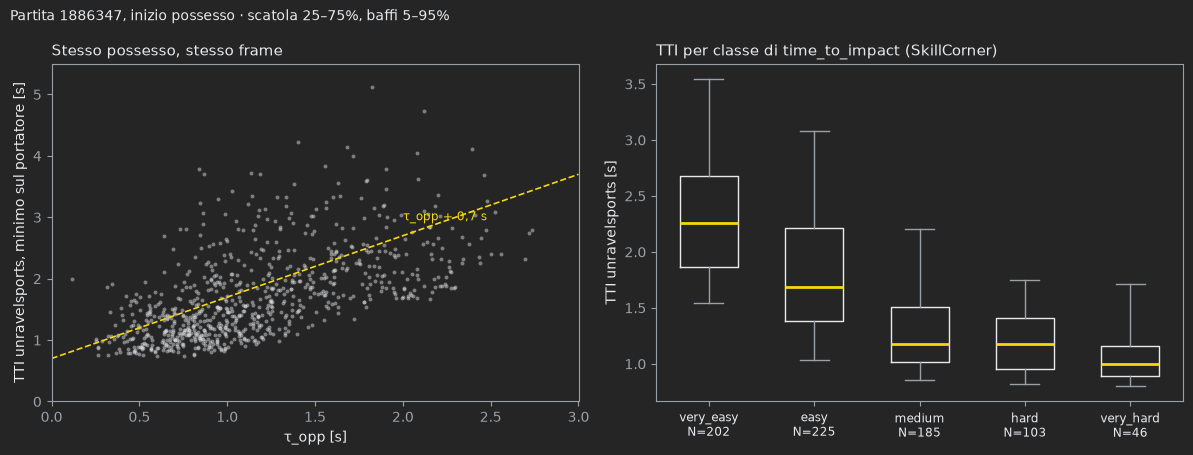

In [4]:
ok = tau[(tau.stato == "ok") & tau.tau_opp_start.notna()]
cl = ok.dropna(subset=["time_to_impact_start_id"])
display(pd.DataFrame({
    "N": [len(ok), len(cl), len(cl)],
    "ρ di Spearman": [spearmanr(ok.tau_opp_start, ok.pi_tti_start)[0],
                      spearmanr(cl.time_to_impact_start_id, cl.pi_tti_start)[0],
                      spearmanr(cl.time_to_impact_start_id, cl.tau_opp_start)[0]],
}, index=["τ_opp ~ TTI unravelsports", "time_to_impact ~ TTI unravelsports", "time_to_impact ~ τ_opp"]).round(3))
display(ok[["tau_opp_start", "pi_tti_start"]].describe().T.round(2))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), facecolor=BG)
for a in (a1, a2):
    a.set_facecolor(BG); a.tick_params(colors=MUTED)
    for s in a.spines.values():
        s.set_color(MUTED)

a1.scatter(ok.tau_opp_start, ok.pi_tti_start, s=8, color=INK, alpha=0.45, lw=0)
lim = np.array([0, 3])
a1.plot(lim, lim + 0.7, color=SCIA, lw=1.2, ls="--")
a1.text(2.0, 2.95, "τ_opp + 0,7 s", color=SCIA, fontsize=8.5)
a1.set_xlim(0, 3); a1.set_ylim(0, 5.5)
a1.set_xlabel("τ_opp [s]", color=INK); a1.set_ylabel("TTI unravelsports, minimo sul portatore [s]", color=INK)
a1.set_title("Stesso possesso, stesso frame", color=INK, loc="left", fontsize=10.5)

ETICHETTE = ["very_easy", "easy", "medium", "hard", "very_hard"]
gruppi = [cl.loc[cl.time_to_impact_start_id == k, "pi_tti_start"] for k in range(1, 6)]
a2.boxplot(gruppi, whis=(5, 95), showfliers=False, widths=0.55,
           boxprops=dict(color=INK), medianprops=dict(color=SCIA, lw=2),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
a2.set_xticks(range(1, 6), [f"{e}\nN={len(g)}" for e, g in zip(ETICHETTE, gruppi)], color=INK, fontsize=8.5)
a2.set_ylabel("TTI unravelsports [s]", color=INK)
a2.set_title("TTI per classe di time_to_impact (SkillCorner)", color=INK, loc="left", fontsize=10.5)
fig.suptitle(f"Partita {MATCH_ID}, inizio possesso · scatola 25–75%, baffi 5–95%", color=INK, x=0.01, ha="left", fontsize=10)
plt.tight_layout()
plt.show()

**Cosa si vede.**

- **TTI e τ_opp concordano poco** (ρ = 0,65), e meno di quanto entrambi
  concordino con altro: `time_to_impact` va con τ_opp a −0,86 e con il TTI a
  −0,67. Le differenze di costruzione (bersaglio a 1 s, reazione fissa, corsa a
  velocità costante) pesano più del fatto che siano tutte e due "tempi di
  arrivo".
- **Il TTI non è τ_opp spostato di 0,7 s.** Molti punti stanno sotto la retta
  τ_opp + 0,7. Correre subito a 12 m/s dopo la reazione è più veloce che
  accelerare con l'attrito del modello di Narizuka, e il bersaglio a 1 s spesso
  viene incontro al difensore.
- **Dove la pressione è alta, il TTI distingue poco.** Sotto τ_opp ≈ 1 s i valori
  si schiacciano fra 0,8 e 1,5 s; a destra `medium`, `hard` e `very_hard` hanno
  mediane quasi uguali (1,17 / 1,17 / 1,00 s). È la soglia di 0,7 s, più la
  scelta di prendere il minimo su 11 difensori.

Il confronto riguarda **una misura derivata** (il minimo della colonna del
portatore), non la Pressing Intensity come la usa Bekkers, che lavora sulle
probabilità e sull'intera matrice. Il risultato dice che il TTI non sostituisce
τ_opp come pressione sul portatore, non che la Pressing Intensity sia
sbagliata.

## Cosa resta aperto

- **Una partita sola.** I numeri vanno rifatti sulle 20 prima di citarli.
- **Il 16% di possessi con la squadra in possesso discordante**: decidere come
  trattarli (vedi §2).
- **Quanto pesa la soglia di 0,7 s.** Rieseguire il `fit` con `reaction_time`
  più basso direbbe se l'accordo con τ_opp e con `time_to_impact` cresce.
- **Usare la PTI invece del TTI.** È la grandezza che unravelsports considera la
  Pressing Intensity vera e propria; il confronto qui usa il TTI perché è nella
  stessa unità di τ_opp.